# **Import Libraries**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error

# **Load Dataset**

In [18]:
df = pd.read_csv("airline_traffic_big_dataset.csv")
df.head()

,Date,Passengers,Flights,Avg_Delay_Minutes,Distance_km
0,2015-01-01,259,154,4,2656
1,2015-01-02,241,150,38,2081
2,2015-01-03,433,64,51,2787
3,2015-01-04,293,105,42,1358
4,2015-01-05,464,150,38,1305


In [19]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               2192 non-null   object
 1   Passengers         2192 non-null   int64 
 2   Flights            2192 non-null   int64 
 3   Avg_Delay_Minutes  2192 non-null   int64 
 4   Distance_km        2192 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 85.8+ KB


,Passengers,Flights,Avg_Delay_Minutes,Distance_km
count,2192.000000,2192.000000,2192.000000,2192.000000
mean,296.673814,126.125912,29.785584,1628.046989
std,118.085890,43.260524,17.069985,807.236123
min,100.000000,50.000000,0.000000,200.000000
25%,190.000000,88.750000,15.000000,942.000000
50%,297.000000,127.000000,30.000000,1634.500000
75%,398.250000,164.000000,44.000000,2314.000000
max,499.000000,199.000000,59.000000,2999.000000


# **Data Preprocessing**

In [20]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.asfreq('MS')   # Monthly Start frequency
df = df.fillna(method='ffill')

/tmp/ipykernel_3094/1111399329.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


# **EDA**

## **Time Series Plot**

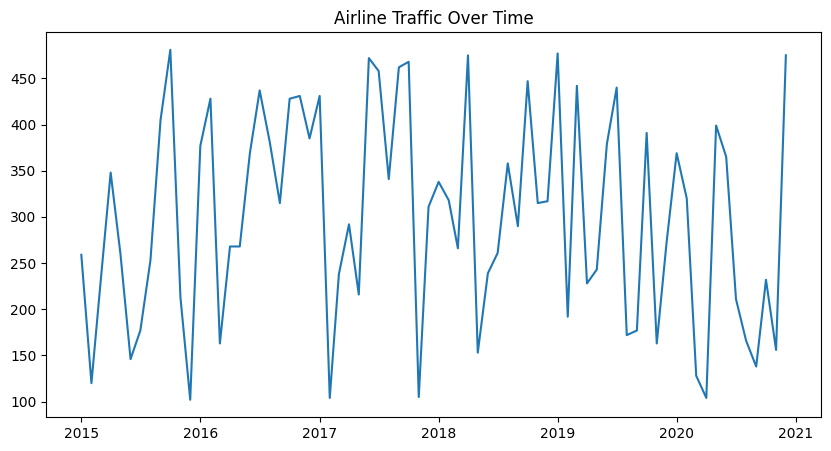

In [21]:
plt.figure(figsize=(10,5))
plt.plot(df['Passengers'])
plt.title("Airline Traffic Over Time")
plt.show()

## **Rolling Mean & Std**

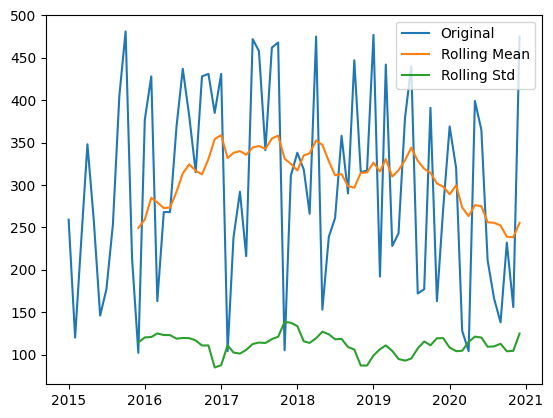

In [22]:
rolling_mean = df['Passengers'].rolling(12).mean()
rolling_std = df['Passengers'].rolling(12).std()

plt.plot(df['Passengers'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.show()

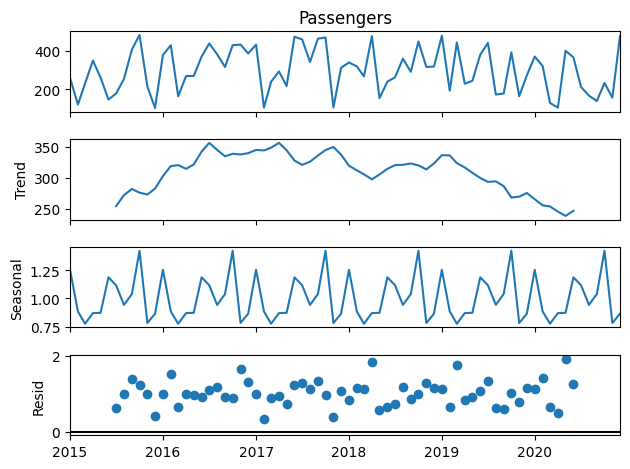

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df['Passengers'], model='multiplicative')
decompose.plot()
plt.show()

**Stationarity Check (ADF Test)**

In [24]:
result = adfuller(df['Passengers'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -7.52181364149601
p-value: 3.7734178545076555e-11


**Differencing**

In [25]:
df_diff = df['Passengers'].diff().dropna()

In [26]:
adfuller(df_diff)

(np.float64(-4.858982430295418),
 np.float64(4.1885849850145555e-05),
 9,
 61,
 {'1%': np.float64(-3.542412746661615),
  '5%': np.float64(-2.910236235808284),
  '10%': np.float64(-2.5927445767266866)},
 np.float64(727.8772159766162))

**Train-Test Split**

In [27]:
train = df[:'2018']
test = df['2019':]

## **ARIMA Model**

In [28]:
model_arima = ARIMA(train['Passengers'], order=(2,1,2))
model_arima_fit = model_arima.fit()

forecast_arima = model_arima_fit.forecast(steps=len(test))

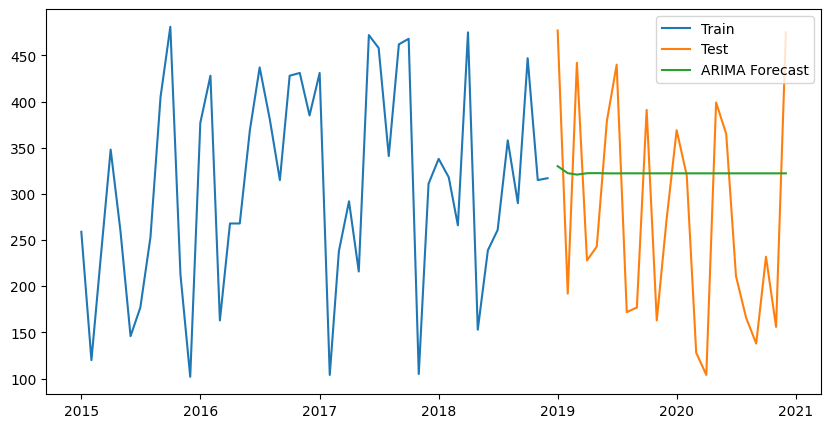

In [29]:
plt.figure(figsize=(10,5))
plt.plot(train['Passengers'], label='Train')
plt.plot(test['Passengers'], label='Test')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.show()

# **SARIMA Model (Seasonality)**

In [30]:
model_sarima = SARIMAX(train['Passengers'],
                       order=(2,1,2),
                       seasonal_order=(1,1,1,12))

model_sarima_fit = model_sarima.fit()

forecast_sarima = model_sarima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


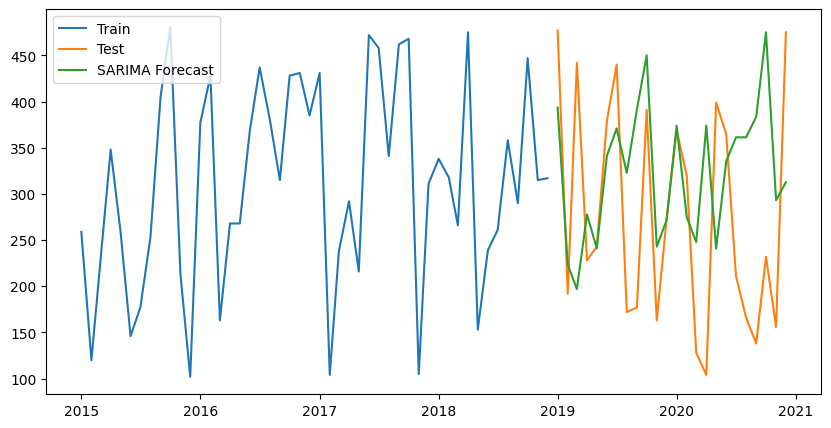

In [31]:
plt.figure(figsize=(10,5))
plt.plot(train['Passengers'], label='Train')
plt.plot(test['Passengers'], label='Test')
plt.plot(test.index, forecast_sarima, label='SARIMA Forecast')
plt.legend()
plt.show()

# **Model Evaluation**

In [32]:
rmse_arima = np.sqrt(mean_squared_error(test['Passengers'], forecast_arima))
rmse_sarima = np.sqrt(mean_squared_error(test['Passengers'], forecast_sarima))

print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)

ARIMA RMSE: 127.00999957895571
SARIMA RMSE: 143.70210185174363


# **Future Forecast (Next 12 Months)**

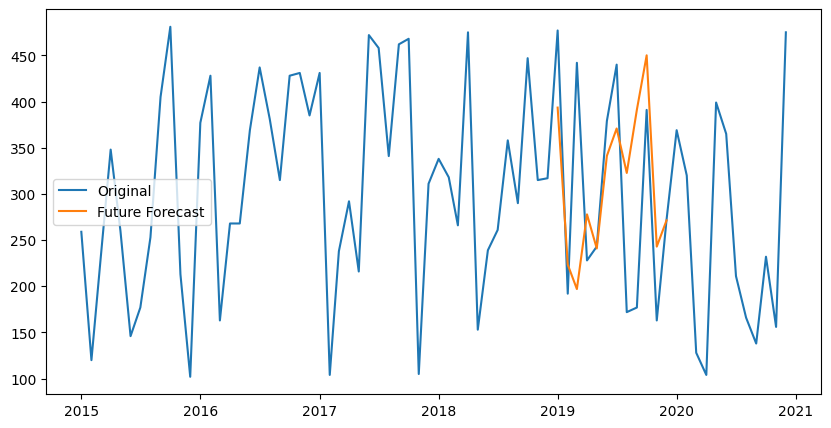

In [33]:
future = model_sarima_fit.forecast(steps=12)

plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label='Original')
plt.plot(future, label='Future Forecast')
plt.legend()
plt.show()

# **Final Conclusion**

ARIMA → Works for non-seasonal data

SARIMA → Best for seasonal patterns (like airline traffic)

Usually SARIMA performs better for this dataset